# Daniyal Khan || 221A061 || 19

In [ ]:
# Daniyal Khan || 19

!pip install youtube-comment-downloader textblob emoji nltk wordcloud matplotlib


In [2]:
# Daniyal Khan || 19
from youtube_comment_downloader import YoutubeCommentDownloader
from textblob import TextBlob
import emoji
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud


In [3]:
# Daniyal Khan || 19
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
# Daniyal Khan || 19
video_url = "https://www.youtube.com/watch?v=WGJJIrtnfpk"

downloader = YoutubeCommentDownloader()
comments = []

for comment in downloader.get_comments_from_url(video_url, sort_by=0):
    comments.append(comment['text'])

print("Total comments fetched:", len(comments))
comments[:5]


Total comments fetched: 1236


['Got a question on the topic? Please share it in the comment section below and our experts will answer it for you. For Python Programming Certification Curriculum, Visit our Website: https://bit.ly/2Y58PfN (Use Code "𝐘𝐎𝐔𝐓𝐔𝐁𝐄𝟐𝟎") 🔴Subscribe to Edureka YouTube channel for latest video updates: http://bit.ly/2ADbbb1\nBelow is the video timestamp:\n1:55 What is Python?\n3:40 Why is Python popular?\n4:55 Features of Python\n6:50 Where is Python used in the industry?\n7:50 Learning Path\n9:15 Career Opportunities\n10:30 How Netflix use Python?\n11:55 How does it use Python?\n18:15 Python Developer Salary\n18:50 Who is Python Developer?\n19:20 Python Developer Job Trends\n21:55 How to become a Python Developer?\n23:05 Who is a Python developer?\n33:50 Job Roles\n41:40 Emerging Job Roles\n44:30 Road Map\n47:05 Python Installation\n54:30 How to run a Python program?\n58:35 Best IDE for Python\n59:35 What is an IDE?\n59:50 Features of an IDE\n1:00:50 Best IDEs of Python\n1:07:40 PyCharm Tutoria

In [6]:
# Daniyal Khan || 19
sentiment_count = {"Positive": 0, "Negative": 0, "Neutral": 0}

for text in comments:
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        sentiment_count["Positive"] += 1
    elif polarity < 0:
        sentiment_count["Negative"] += 1
    else:
        sentiment_count["Neutral"] += 1

sentiment_count


{'Positive': 857, 'Negative': 29, 'Neutral': 350}

In [7]:
# Daniyal Khan || 19
def extract_emojis(text):
    return [char for char in text if char in emoji.EMOJI_DATA]

emoji_list = []

for text in comments:
    emoji_list.extend(extract_emojis(text))

emoji_frequency = Counter(emoji_list)
emoji_frequency.most_common(10)


[('❤', 98),
 ('👍', 71),
 ('🙏', 50),
 ('😊', 46),
 ('🏻', 17),
 ('👌', 16),
 ('👏', 14),
 ('♥', 13),
 ('😍', 12),
 ('😭', 8)]

In [8]:
# Daniyal Khan || 19
stop_words = set(stopwords.words('english'))
words = []

for text in comments:
    for word in text.lower().split():
        if word.isalpha() and word not in stop_words:
            words.append(word)

topic_trends = Counter(words)
topic_trends.most_common(10)


[('python', 520),
 ('channel', 257),
 ('thank', 222),
 ('edureka', 153),
 ('learning', 151),
 ('thanks', 148),
 ('subscribe', 147),
 ('glad', 126),
 ('video', 122),
 ('course', 119)]

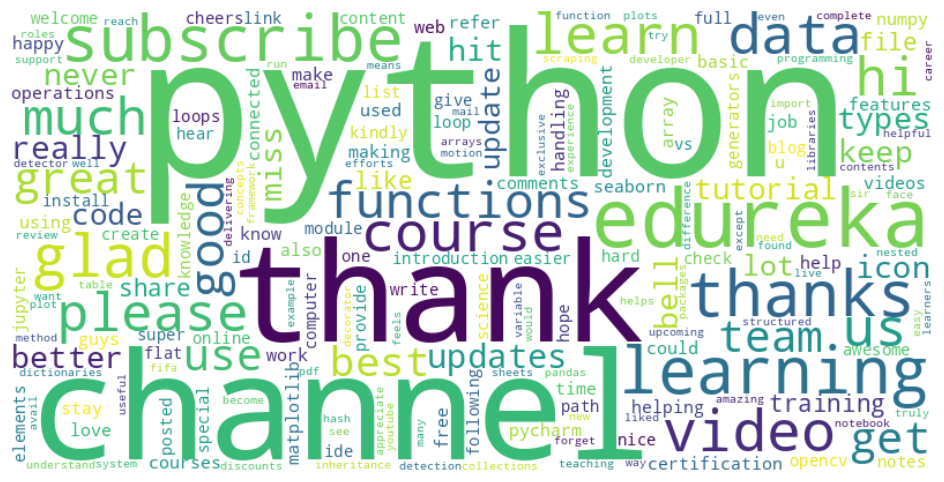

In [9]:
# Daniyal Khan || 19
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(topic_trends)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


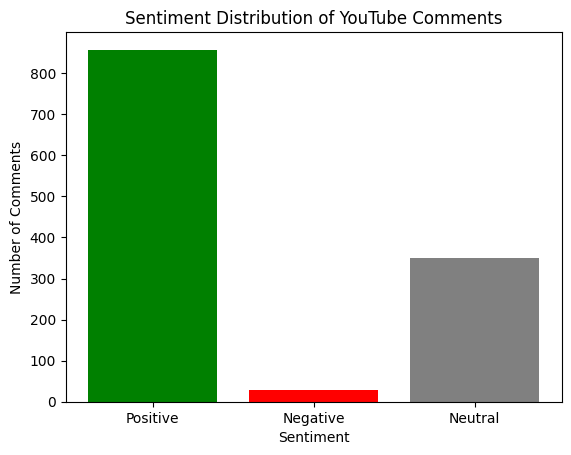

In [10]:
# Daniyal Khan || 19
plt.bar(sentiment_count.keys(), sentiment_count.values(), color=['green','red','gray'])
plt.title("Sentiment Distribution of YouTube Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()


In [11]:
# Daniyal Khan || 19
business_insights = {
    "Total Comments": len(comments),
    "Positive %": round(sentiment_count["Positive"] * 100 / len(comments), 2),
    "Negative %": round(sentiment_count["Negative"] * 100 / len(comments), 2),
    "Neutral %": round(sentiment_count["Neutral"] * 100 / len(comments), 2),
    "Top Topics": topic_trends.most_common(5),
    "Top Emojis": emoji_frequency.most_common(5)
}

business_insights


{'Total Comments': 1236,
 'Positive %': 69.34,
 'Negative %': 2.35,
 'Neutral %': 28.32,
 'Top Topics': [('python', 520),
  ('channel', 257),
  ('thank', 222),
  ('edureka', 153),
  ('learning', 151)],
 'Top Emojis': [('❤', 98), ('👍', 71), ('🙏', 50), ('😊', 46), ('🏻', 17)]}